well-structured ANN implementation for Task 1
Arshad Ali - 403515
Sir Yasir Nawaz Memon

In [1]:

# ──────────────────────────────────────────────────────────────
# Install / verify libraries (run this first)
# ──────────────────────────────────────────────────────────────
import tensorflow as tf
import sklearn
import pandas as pd
import numpy as np
import matplotlib

print("TensorFlow :", tf.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Pandas      :", pd.__version__)
print("NumPy       :", np.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("\n✅ All libraries ready — no installation needed in Colab!")


TensorFlow : 2.19.0
Scikit-learn: 1.6.1
Pandas      : 2.2.2
NumPy       : 2.0.2
Matplotlib  : 3.10.0

✅ All libraries ready — no installation needed in Colab!


In [2]:


# ──────────────────────────────────────────────────────────────
# 2 – Import all required modules
# ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For reproducibility – same results every run
tf.random.set_seed(42)
np.random.seed(42)

print("✅ All imports successful!")


✅ All imports successful!


In [3]:
# ──────────────────────────────────────────────────────────────
# 3 – Load and explore the dataset
# ──────────────────────────────────────────────────────────────

# California Housing: predicts median house value from 8 numerical features

data = fetch_california_housing(as_frame=True)
df   = data.frame

print("=" * 55)
print("  DATASET: California Housing")
print("=" * 55)
print(f"  Rows     : {df.shape[0]}")
print(f"  Columns  : {df.shape[1]}")
print(f"  Features : {list(data.feature_names)}")
print(f"  Target   : MedHouseVal (house price in $100k)\n")
print(df.describe())   # Statistical summary of all columns


  DATASET: California Housing
  Rows     : 20640
  Columns  : 9
  Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Target   : MedHouseVal (house price in $100k)

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  

In [4]:
# ──────────────────────────────────────────────────────────────
# 4 – Data Preprocessing
# ──────────────────────────────────────────────────────────────

# Step A: Handle missing values
# (fill with median – robust to outliers)

missing = df.isnull().sum().sum()
df.fillna(df.median(numeric_only=True), inplace=True)
print(f"Missing values found & handled: {missing}")

# Step B: Separate features and target
X = df.drop(columns=["MedHouseVal"])   # Input features
y = df["MedHouseVal"]                  # Target variable

# Step C: Train / Test split  (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train size : {X_train.shape[0]} samples")
print(f"Test  size : {X_test.shape[0]} samples")

# Step D: Feature Scaling
# StandardScaler → each feature becomes mean=0, std=1
# IMPORTANT: fit ONLY on training data to avoid data leakage

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling (StandardScaler) applied ✅")

Missing values found & handled: 0
Train size : 16512 samples
Test  size : 4128 samples
Feature scaling (StandardScaler) applied ✅


In [5]:
# ──────────────────────────────────────────────────────────────
# 5 – Build the ANN Model
# ──────────────────────────────────────────────────────────────
model = keras.Sequential([

    # Input layer – 8 features going in
    layers.Input(shape=(X_train_scaled.shape[1],), name="Input_Layer"),

    # Hidden Layer 1 – 128 neurons
    # ReLU: f(x) = max(0,x) → avoids vanishing gradient problem

    layers.Dense(128, activation="relu", name="Hidden_Layer_1"),
    layers.BatchNormalization(name="BatchNorm_1"),  # Stabilises training
    layers.Dropout(0.2, name="Dropout_1"),          # 20% dropout → reduces overfitting

    # Hidden Layer 2 – 64 neurons

    layers.Dense(64, activation="relu", name="Hidden_Layer_2"),
    layers.BatchNormalization(name="BatchNorm_2"),
    layers.Dropout(0.2, name="Dropout_2"),

    # Hidden Layer 3 – 32 neurons

    layers.Dense(32, activation="relu", name="Hidden_Layer_3"),

    # Output Layer – 1 neuron, Linear activation
    # Linear = no squashing → suitable for regression (continuous output)

    layers.Dense(1, activation="linear", name="Output_Layer"),

], name="ANN_HousePrices")

# Print full architecture summary
model.summary()


Model: "ANN_HousePrices"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [6]:
# ──────────────────────────────────────────────────────────────
# 6 – Compile the Model
# ──────────────────────────────────────────────────────────────
model.compile(

    # Adam optimizer: adaptive learning rate, fast convergence
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # MSE loss: heavily penalises large errors → good for regression
    loss="mean_squared_error",

    # MAE reported as extra metric (same units as house price)
    metrics=["mae"]
)

print("✅ Model compiled!")
print("   Optimizer : Adam  (lr=0.001)")
print("   Loss      : Mean Squared Error (MSE)")
print("   Metric    : Mean Absolute Error (MAE)")


✅ Model compiled!
   Optimizer : Adam  (lr=0.001)
   Loss      : Mean Squared Error (MSE)
   Metric    : Mean Absolute Error (MAE)


In [7]:
# ──────────────────────────────────────────────────────────────
# 7 – Train the Model
# ──────────────────────────────────────────────────────────────

# EarlyStopping: stop training if validation loss doesn't improve
# for 10 consecutive epochs → prevents overfitting

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training started...\n")

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,    # 15% of train data used for validation
    epochs=100,               # Max 100 epochs
    batch_size=64,            # 64 samples per weight update
    callbacks=[early_stop],
    verbose=1                 # Show progress bar per epoch
)

print("\n✅ Training complete!")
print(f"   Epochs run      : {len(history.history['loss'])}")
print(f"   Best val loss   : {min(history.history['val_loss']):.4f}")


Training started...

Epoch 1/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.0085 - mae: 0.7422 - val_loss: 0.7999 - val_mae: 0.6570
Epoch 2/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5845 - mae: 0.5677 - val_loss: 0.4996 - val_mae: 0.5102
Epoch 3/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5015 - mae: 0.5214 - val_loss: 0.4232 - val_mae: 0.4602
Epoch 4/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4655 - mae: 0.5003 - val_loss: 0.4079 - val_mae: 0.4419
Epoch 5/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4310 - mae: 0.4793 - val_loss: 0.3793 - val_mae: 0.4257
Epoch 6/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4078 - mae: 0.4641 - val_loss: 0.3712 - val_mae: 0.4213
Epoch 7/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4008 - mae: 0.4580 - val_loss: 0.3644 - val_mae: 0.4155
Epoch 8/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3853 - mae: 0.4501 - val_loss: 0.3688 - val_mae: 0.4136
Epoch 9/100
220/220 ━━━━━━━

In [8]:
# ──────────────────────────────────────────────────────────────
# 8 – Evaluate the Model
# ──────────────────────────────────────────────────────────────

# Predict on unseen test data
y_pred = model.predict(X_test_scaled).flatten()

# Calculate metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("  MODEL EVALUATION ON TEST SET")
print("=" * 45)
print(f"  MSE  (Mean Squared Error)  : {mse:.4f}")
print(f"  RMSE (Root MSE)            : {rmse:.4f}")
print(f"  R²   (Coefficient of Det.) : {r2:.4f}")
print("=" * 45)
print(f"\n  R² = {r2:.4f} means the model explains")
print(f"  {r2*100:.1f}% of the variance in house prices.")


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  MODEL EVALUATION ON TEST SET
  MSE  (Mean Squared Error)  : 0.2907
  RMSE (Root MSE)            : 0.5391
  R²   (Coefficient of Det.) : 0.7782

  R² = 0.7782 means the model explains
  77.8% of the variance in house prices.


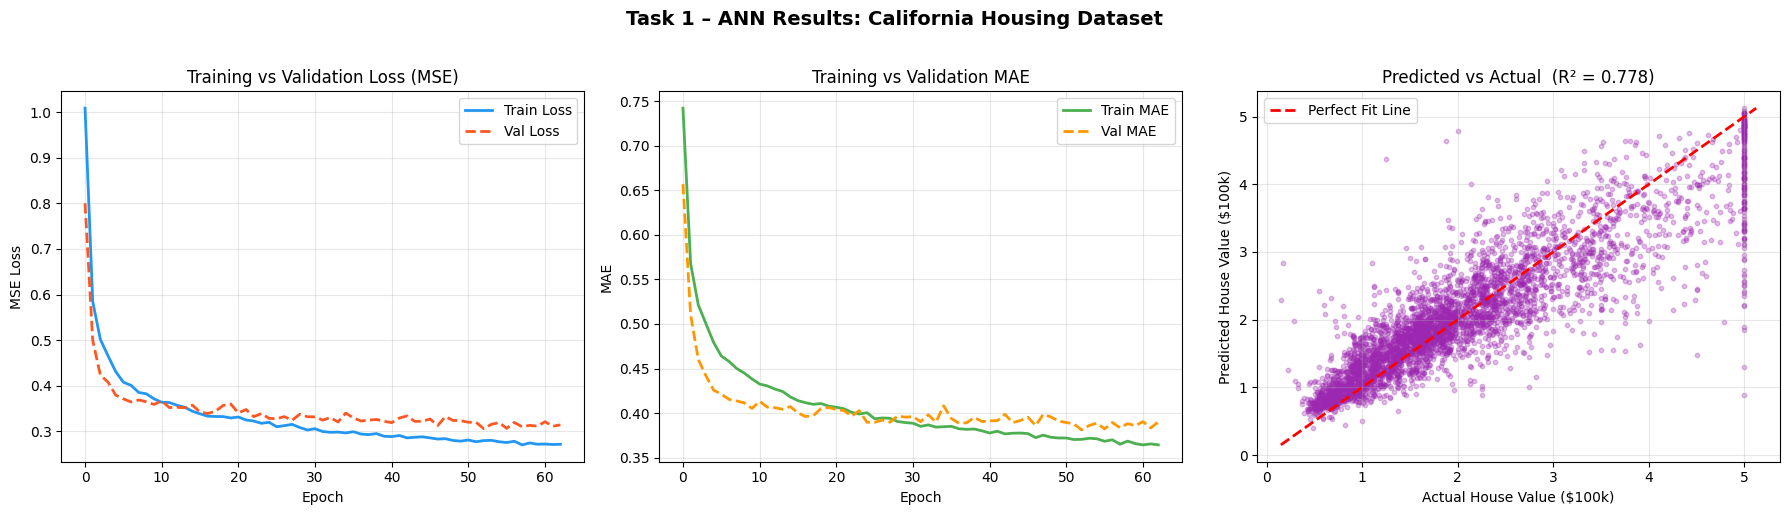

✅ Plot saved as ann_results.png
   (Download from Files panel on the left in Colab)


In [12]:
# ──────────────────────────────────────────────────────────────
# 9 – Plot Results
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Task 1 – ANN Results: California Housing Dataset",
             fontsize=14, fontweight="bold", y=1.02)

# ── Plot 1: Loss Curve (MSE) ────────────────────────────────
axes[0].plot(history.history["loss"],
             label="Train Loss", color="#2196F3", linewidth=2)
axes[0].plot(history.history["val_loss"],
             label="Val Loss", color="#FF5722", linewidth=2, linestyle="--")
axes[0].set_title("Training vs Validation Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: MAE Curve ───────────────────────────────────────
axes[1].plot(history.history["mae"],
             label="Train MAE", color="#4CAF50", linewidth=2)
axes[1].plot(history.history["val_mae"],
             label="Val MAE", color="#FF9800", linewidth=2, linestyle="--")
axes[1].set_title("Training vs Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Plot 3: Predicted vs Actual ─────────────────────────────
axes[2].scatter(y_test, y_pred, alpha=0.3, color="#9C27B0", s=10)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val],
             color="red", linewidth=2, linestyle="--", label="Perfect Fit Line")
axes[2].set_title(f"Predicted vs Actual  (R² = {r2:.3f})")
axes[2].set_xlabel("Actual House Value ($100k)")
axes[2].set_ylabel("Predicted House Value ($100k)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ann_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved as ann_results.png")
print("   (Download from Files panel on the left in Colab)")


In [13]:
# ──────────────────────────────────────────────────────────────
# 10 – Explanation Summary (for your report)
# ──────────────────────────────────────────────────────────────
summary = """
╔══════════════════════════════════════════════════════════════╗
║                   EXPLANATION SUMMARY                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET     : California Housing (tabular, numerical)       ║
║  TASK TYPE   : Regression (predict house price)              ║
║                                                              ║
║  ANN ARCHITECTURE:                                           ║
║    Input  Layer  →  8 neurons  (one per feature)             ║
║    Hidden Layer 1 → 128 neurons                              ║
║    Hidden Layer 2 →  64 neurons                              ║
║    Hidden Layer 3 →  32 neurons                              ║
║    Output Layer  →   1 neuron  (predicted price)             ║
║                                                              ║
║  ACTIVATION FUNCTIONS:                                       ║
║    • ReLU   (hidden) – avoids vanishing gradient             ║
║    • Linear (output) – unbounded, suits regression           ║
║                                                              ║
║  LOSS FUNCTION:                                              ║
║    • MSE – penalises large errors more (squares them)        ║
║                                                              ║
║  OPTIMIZER:                                                  ║
║    • Adam – adaptive learning rate, fast & reliable          ║
║                                                              ║
║  REGULARISATION:                                             ║
║    • Dropout 20%       – prevents overfitting                ║
║    • BatchNormalization – stabilises training                ║
║    • EarlyStopping     – stops before overfitting            ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║                   EXPLANATION SUMMARY                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET     : California Housing (tabular, numerical)       ║
║  TASK TYPE   : Regression (predict house price)              ║
║                                                              ║
║  ANN ARCHITECTURE:                                           ║
║    Input  Layer  →  8 neurons  (one per feature)             ║
║    Hidden Layer 1 → 128 neurons                              ║
║    Hidden Layer 2 →  64 neurons                              ║
║    Hidden Layer 3 →  32 neurons                              ║
║    Output Layer  →   1 neuron  (predicted price)             ║
║                                                              ║
║  ACTIVATION FUNCTIONS:                                       ║
║    • ReLU   (hidden) –